# analyse exploratoire des tendances

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Remplace par le chemin absolu si nécessaire
file_path = 'data/NSE_Training_Subprime_v2.csv'

# Charger le fichier
try:
    df = pd.read_csv(file_path)
    print("Fichier chargé avec succès !")
except FileNotFoundError:
    print(f"Fichier introuvable : {file_path}")
except Exception as e:
    print(f"Erreur lors du chargement du fichier : {e}")


Fichier chargé avec succès !


## # Convertir la colonne 'Price' en format datetime

In [7]:
# Convertir la colonne 'Price' en format datetime
df['Price'] = pd.to_datetime(df['Price'])

# Afficher les premières lignes pour vérifier
print("Aperçu des données :")
display(df.head())

Aperçu des données :


,Price,Adj Close,Close,High,Low,Open,Volume
0,2006-01-01,10959.309570,10959.309570,10968.839844,10684.450195,10718.299805,1117090000
1,2006-01-08,10959.870117,10959.870117,11047.759766,10921.530273,10959.469727,1285110000
2,2006-01-15,10667.389648,10667.389648,10957.870117,10661.150391,10957.870117,1503060000
3,2006-01-22,10907.209961,10907.209961,10932.339844,10666.349609,10668.750000,1953890000
4,2006-01-29,10793.620117,10793.620117,10967.570312,10779.059570,10908.490234,1687430000


## # Informations de base

In [8]:
# Informations de base
print("\nInformations générales :")
print(df.info())

# Statistiques descriptives
print("\nStatistiques descriptives :")
display(df.describe())

# Corrélation entre les colonnes numériques
correlation = df.corr()
print("\nCorrélation entre les colonnes numériques :")
display(correlation)


Informations générales :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Price      157 non-null    datetime64[ns]
 1   Adj Close  157 non-null    float64       
 2   Close      157 non-null    float64       
 3   High       157 non-null    float64       
 4   Low        157 non-null    float64       
 5   Open       157 non-null    float64       
 6   Volume     157 non-null    int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 8.7 KB
None

Statistiques descriptives :


,Price,Adj Close,Close,High,Low,Open,Volume
count,157,157.000000,157.000000,157.000000,157.000000,157.000000,1.570000e+02
mean,2007-07-01 00:00:00,11924.387950,11924.387950,12125.135997,11712.667294,11937.084880,1.273067e+09
min,2006-01-01 00:00:00,8046.419922,8046.419922,8571.299805,7449.379883,8048.089844,4.975100e+08
25%,2006-10-01 00:00:00,11220.959961,11220.959961,11334.959961,11053.169922,11224.870117,1.050600e+09
50%,2007-07-01 00:00:00,12114.099609,12114.099609,12349.669922,11984.759766,12116.509766,1.248940e+09
75%,2008-03-30 00:00:00,12891.860352,12891.860352,13058.450195,12656.559570,12890.759766,1.486630e+09
max,2008-12-28 00:00:00,14093.080078,14093.080078,14198.099609,13950.250000,14092.429688,2.534100e+09
std,NaN,1334.248979,1334.248979,1273.223282,1387.700757,1313.652277,3.358903e+08



Corrélation entre les colonnes numériques :


,Price,Adj Close,Close,High,Low,Open,Volume
Price,1.000000,-0.119883,-0.119883,-0.043633,-0.171191,-0.085307,-0.037691
Adj Close,-0.119883,1.000000,1.000000,0.983050,0.990376,0.972502,-0.306888
Close,-0.119883,1.000000,1.000000,0.983050,0.990376,0.972502,-0.306888
High,-0.043633,0.983050,0.983050,1.000000,0.978304,0.990306,-0.248813
Low,-0.171191,0.990376,0.990376,0.978304,1.000000,0.980166,-0.338522
Open,-0.085307,0.972502,0.972502,0.990306,0.980166,1.000000,-0.266596
Volume,-0.037691,-0.306888,-0.306888,-0.248813,-0.338522,-0.266596,1.000000


## Visualiser la corrélation avec une heatmap

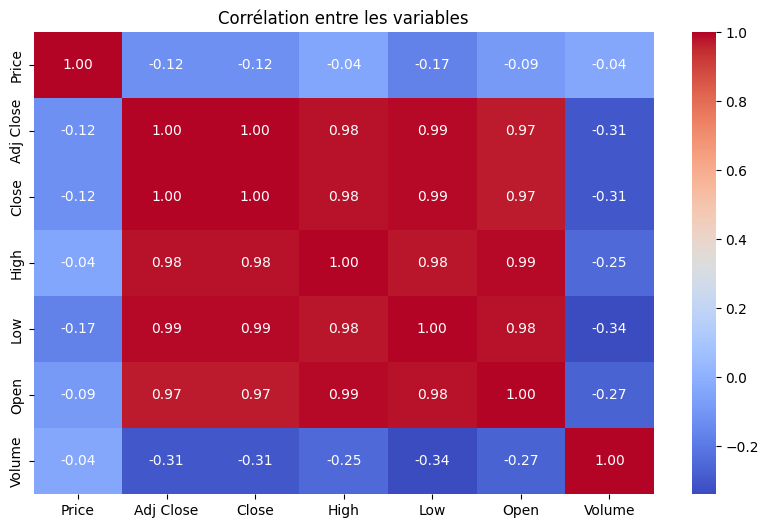

In [9]:
plt.figure(figsize=(10, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Corrélation entre les variables")
plt.show()

## Tracer les tendances des prix

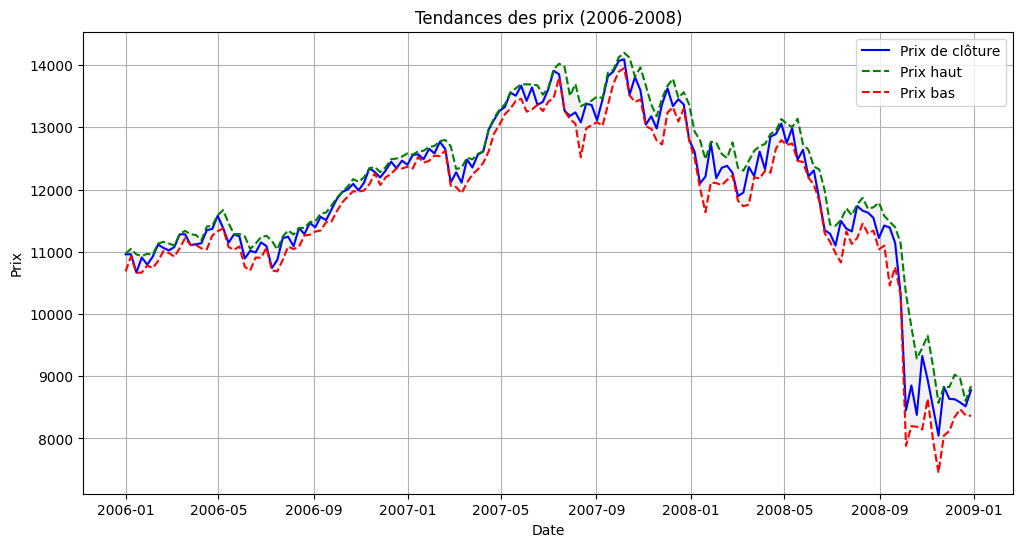

In [10]:
plt.figure(figsize=(12, 6))
plt.plot(df['Price'], df['Close'], label='Prix de clôture', color='blue')
plt.plot(df['Price'], df['High'], label='Prix haut', color='green', linestyle='--')
plt.plot(df['Price'], df['Low'], label='Prix bas', color='red', linestyle='--')
plt.fill_between(df['Price'], df['Low'], df['High'], color='gray', alpha=0.1)
plt.title("Tendances des prix (2006-2008)")
plt.xlabel("Date")
plt.ylabel("Prix")
plt.legend()
plt.grid()
plt.show()

## Analyser les volumes de transactions

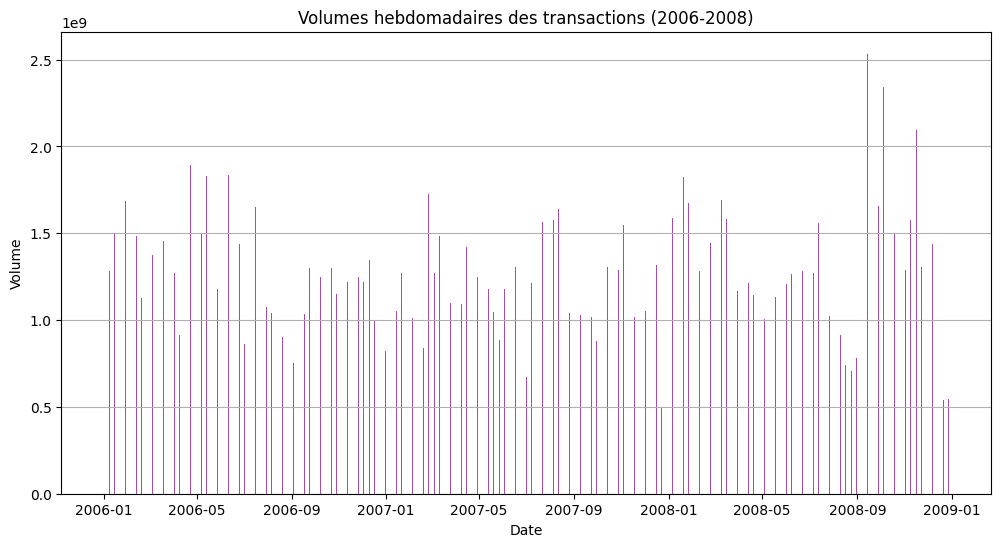

In [11]:
plt.figure(figsize=(12, 6))
plt.bar(df['Price'], df['Volume'], color='purple', alpha=0.7)
plt.title("Volumes hebdomadaires des transactions (2006-2008)")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.grid(axis='y')
plt.show()

## Distribution des prix de clôture

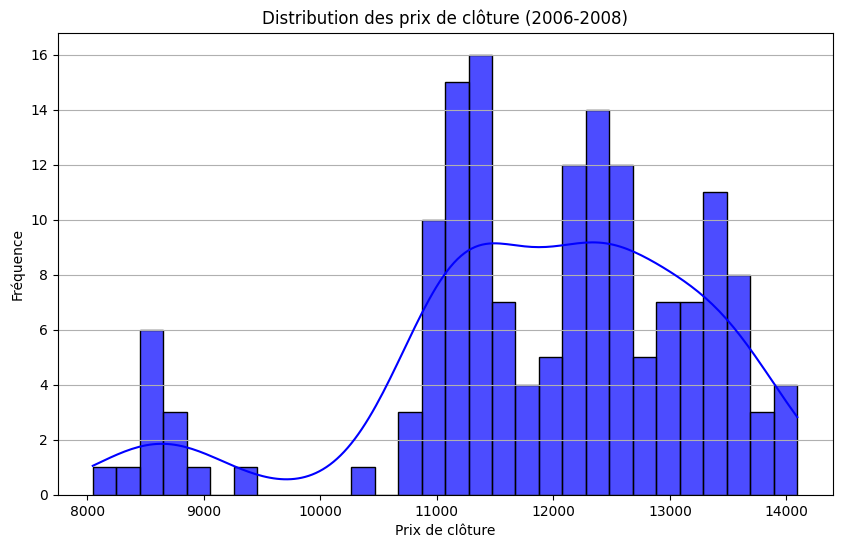

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Close'], kde=True, bins=30, color='blue', alpha=0.7)
plt.title("Distribution des prix de clôture (2006-2008)")
plt.xlabel("Prix de clôture")
plt.ylabel("Fréquence")
plt.grid(axis='y')
plt.show()